In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
import time

In [152]:
#from modules.data_collection import scrape
#scrape()

In [153]:
data1 = pd.read_csv("data/products1.csv")
data2 = pd.read_csv("data/products2.csv")

In [154]:
data1.head()

,Name,Price,Category
0,Spaghetti 500g EXTRA,"90,00 د.ج",Pâtes et Couscous
1,Spaghetti 500g EXTRA,"90,00 د.ج",Pâtes et Couscous
2,FUSILLI 500g Garrido,"115,00 د.ج",Pâtes et Couscous
3,FUSILLI 500g Garrido,"115,00 د.ج",Pâtes et Couscous
4,NIDI 500G محبوبة,"180,00 د.ج",Pâtes et Couscous


In [155]:
data1.duplicated().sum()

np.int64(189)

In [156]:
data1.isna().sum()

Name        0
Price       0
Category    0
dtype: int64

In [157]:
data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Name      378 non-null    str  
 1   Price     378 non-null    str  
 2   Category  378 non-null    str  
dtypes: str(3)
memory usage: 9.0 KB


In [158]:
data1.describe()


,Name,Price,Category
count,378,378,378
unique,189,63,8
top,Spaghetti 500g EXTRA,"95,00 د.ج",Pâtes et Couscous
freq,2,34,138


In [159]:
# drop the duplicates in data1
data1.drop_duplicates(inplace=True)

In [160]:
data1.describe()

,Name,Price,Category
count,189,189,189
unique,189,63,8
top,Spaghetti 500g EXTRA,"95,00 د.ج",Pâtes et Couscous
freq,1,17,69


In [161]:
# clean the price field (to convert it from str to float)
data1["Price"] = (
    data1["Price"]
    .astype(str)
    .str.replace("د.ج", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.replace(" ", "", regex=False)
    .str.strip()
)

In [162]:
data1.head()

,Name,Price,Category
0,Spaghetti 500g EXTRA,90.00,Pâtes et Couscous
2,FUSILLI 500g Garrido,115.00,Pâtes et Couscous
4,NIDI 500G محبوبة,180.00,Pâtes et Couscous
6,GNOCCHETTI 500G البركة,110.00,Pâtes et Couscous
8,CHAKHCHOUKHA 500G البركة,110.00,Pâtes et Couscous


In [163]:
data1.tail()

,Name,Price,Category
368,BISCUITS MAXON XL CACAO 400G,180.00,Epicerie-Sucree
370,BISCUITS MEGA DREAM CHOCOLAT 320G,110.00,Epicerie-Sucree
372,BISCUITS MEGA DREAM FRAISE 320G,110.00,Epicerie-Sucree
374,PATE A TARTINER OPTILLA 700G,470.00,Epicerie-Sucree
376,CHOCOLAT POUDRE NOVA 500G,325.00,Epicerie-Sucree


In [164]:
# convert the price to numeric values
data1["Price"] = pd.to_numeric(data1["Price"], errors="coerce")

In [165]:
data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 189 entries, 0 to 376
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      189 non-null    str    
 1   Price     182 non-null    float64
 2   Category  189 non-null    str    
dtypes: float64(1), str(2)
memory usage: 4.6 KB


In [166]:
data2.head()

,Name,Price,Category
0,Ail,900 DA,Fruits et Légumes
1,Ail Rouge en Vrac,60 DA – 600 DA,Fruits et Légumes
2,Ananas,"120 DA – 1,200 DA",Fruits et Légumes
3,Anchois Vrac,"250 DA – 2,500 DA",Fruits et Légumes
4,Artichaut 1kg,250 DA,Fruits et Légumes


In [167]:
data2.tail()

,Name,Price,Category
137,Semoule Fine Mama 5Kg,390 DA,Semoulerie et Farine
138,Semoule Grosse Mama 1KG,100 DA,Semoulerie et Farine
139,Semoule Grosse Mama 2kg,170 DA,Semoulerie et Farine
140,Semoule Moyenne Mama 1kg,90 DA,Semoulerie et Farine
141,Semoule Moyenne Mama 2kg,235 DA,Semoulerie et Farine


In [168]:
data2.describe()

,Name,Price,Category
count,142,142,142
unique,130,77,3
top,Pomme Jaune Super,"1,200 DA",Fruits et Légumes
freq,2,9,96


In [169]:
data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Name      142 non-null    str  
 1   Price     142 non-null    str  
 2   Category  142 non-null    str  
dtypes: str(3)
memory usage: 3.5 KB


In [170]:
# drop duplicates in data2
data2.drop_duplicates(inplace=True)

In [171]:
data2.describe()

,Name,Price,Category
count,130,130,130
unique,130,77,3
top,Ail,"1,200 DA",Fruits et Légumes
freq,1,9,84


In [172]:
# clean the price field
data2["Price"] = (
    data2["Price"]
    .astype(str)
    .str.replace("DA", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.strip()
)

In [173]:
data2.head()

,Name,Price,Category
0,Ail,900,Fruits et Légumes
1,Ail Rouge en Vrac,60 –600,Fruits et Légumes
2,Ananas,120 –1200,Fruits et Légumes
3,Anchois Vrac,250 –2500,Fruits et Légumes
4,Artichaut 1kg,250,Fruits et Légumes


In [174]:
def convert_value(val):
    if pd.isna(val):
        return np.nan
        
    val = val.replace("–", "-")
    
    if "-" in val:
        parts = val.split("-")
        try:
            nums = [float(p) for p in parts if p != ""]
            return sum(nums) / len(nums)
        except:
            return np.nan
    try:
        return float(val)
    except:
        return np.nan
"""
    convert the price to numeric values (float) and for those who are represented by intervals
    we compute them by the mean
"""
data2["Price"] = data2["Price"].apply(convert_value)

In [175]:
data2.head()

,Name,Price,Category
0,Ail,900.0,Fruits et Légumes
1,Ail Rouge en Vrac,330.0,Fruits et Légumes
2,Ananas,660.0,Fruits et Légumes
3,Anchois Vrac,1375.0,Fruits et Légumes
4,Artichaut 1kg,250.0,Fruits et Légumes


In [176]:
data2.info()

<class 'pandas.DataFrame'>
Index: 130 entries, 0 to 141
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      130 non-null    str    
 1   Price     130 non-null    float64
 2   Category  130 non-null    str    
dtypes: float64(1), str(2)
memory usage: 4.1 KB


In [177]:
# concatenate data1 and data2
data = pd.concat([data1, data2], axis=0)
data.describe()

,Price
count,312.000000
mean,273.958333
std,305.327590
min,25.000000
25%,95.000000
50%,165.000000
75%,296.250000
max,1925.000000


In [178]:
data.info()

<class 'pandas.DataFrame'>
Index: 319 entries, 0 to 141
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      319 non-null    str    
 1   Price     312 non-null    float64
 2   Category  319 non-null    str    
dtypes: float64(1), str(2)
memory usage: 10.0 KB


In [179]:
# drop the nan rows in the data (since they are only 7 rows)
data.dropna(inplace=True)

In [180]:
data.info()

<class 'pandas.DataFrame'>
Index: 312 entries, 0 to 141
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      312 non-null    str    
 1   Price     312 non-null    float64
 2   Category  312 non-null    str    
dtypes: float64(1), str(2)
memory usage: 9.8 KB


In [181]:
import re

In [182]:
# a function that extracts the quantity from the name with regex (regular expressions)
def extract_quantity(name, category):
    n = name.lower()
    # fruits & vegetables -> always per kg
    if category in ('Fruits et Légumes', 'Fruits Secs'):
        m = re.search(r'(\d+)\s*kg\b', n)
        if m:
            return f"{int(m.group(1)) * 1000} g"
        return "1000 g"
    # drinks -> convert to ml
    if category == 'Boisson':
        m = re.search(r'(\d+)\s*cl\b', n)
        if m:
            return f"{int(m.group(1)) * 10} ml"
        m = re.search(r'(\d+(?:[.,]\d+)?)\s*l\b', n)
        if m:
            return f"{int(float(m.group(1)) * 1000)} ml"
    # everything else -> look for g or kg in name
    m = re.search(r'(\d+)\s*g\b', n)
    if m:
        return f"{m.group(1)} g"
    m = re.search(r'(\d+)\s*kg\b', n)
    if m:
        return f"{int(m.group(1)) * 1000} g"
    return np.nan

data['Quantity'] = data.apply(
    lambda row: extract_quantity(row['Name'], row['Category']), axis=1
)

In [183]:
data.isna().sum()

Name         0
Price        0
Category     0
Quantity    27
dtype: int64

In [184]:
# then I have assigned qunatitites manually for products that does'nt contain quantities in their names (23 product)
data = pd.read_csv("data/products_manually_modified.csv")

In [185]:
data.isna().sum()

Name        0
Price       0
Category    0
Quantity    4
dtype: int64

In [186]:
# drop the 4 products that I didn't find their quantities
data.dropna(inplace=True)

In [187]:
# add nutritional unit field
data['Nutritional Unit'] = data['Quantity'].apply(
    lambda q: 'per 100 ml' if 'ml' in str(q) else 'per 100 g'
)

In [188]:
# from nutrition_db we map each product to it's nutritional unit
# produce_name_map is a dictionary that maps fruits and vegetables to their values
# here the order of mapping matters 
from data.nutrition_data import NUTRITION_DB, PRODUCE_NAME_MAP
def map_product_to_key(row):
    name = str(row['Name']).lower()
    cat  = str(row['Category'])

    if "confiture" in name:       return 'jam'
    if any(x in name for x in ["gazeuse", "slim", "selecto", "coca"]): return 'soda'
    if any(x in name for x in ["biscuits", "galette", "céréales"]):       return 'biscuits'
    for key in sorted(PRODUCE_NAME_MAP, key=len, reverse=True):
        if key in name:
            return PRODUCE_NAME_MAP[key]
    if "couscous" in name:        return 'couscous'
    if cat == 'Pâtes et Couscous': return 'dry_pasta'
    if any(x in name for x in ["candy choco", "chocolat"]): return 'chocolate_milk'
    if "lait" in name:
        return 'skim_milk' if any(x in name for x in ["ecreme", "silhouette"]) else 'whole_milk'
    if "margarine" in name:       return 'margarine'
    if "fromage"   in name:       return 'processed_cheese'
    if "riz"       in name:       return 'rice'
    if "lentille"  in name:       return 'lentils'
    if "pois chiche" in name:     return 'chickpeas'
    if "farine"    in name:       return 'flour'
    if "semoule"   in name:       return 'semolina'
    if "sucre"     in name:       return 'sugar'
    if "thon" in name:
        if "tomate"  in name:     return 'tuna_tomato'
        return 'tuna_natural' if "naturel" in name else 'tuna_in_oil'
    if "huile" in name or cat == 'Huiles et Vinaigre':
        if "vinaigre"   in name:  return 'vinegar'
        if "mayonnaise" in name:  return 'mayonnaise'
        return 'oil'
    if any(x in name for x in ["gaufrette", "gullon"]): return 'biscuits'
    if "pois cassés" in name:     return 'split_peas'
    if any(x in name for x in ["cafe", "café"]):  return 'coffee'
    if any(x in name for x in ["haraissa", "hrouss", "hrissa", "harissa"]): return 'harissa'
    if "haricot" in name and cat == "Légumes Secs": return 'kidney_beans'
    if "tartiner" in name:        return 'spread'

    TOMATO_FRESH_RE = re.compile(r'^(tomate)$')
    if "tomate" in name:
        if TOMATO_FRESH_RE.match(name):
            return 'tomato'
        else:
            return 'tomato_paste'
    return 'other'

data['Nutri_Key'] = data.apply(map_product_to_key, axis=1)

nutri_cols = ['Calories (g)', 'Protein (g)', 'Total_Fat (g)', 'Saturated_Fat (g)', 'Carbohydrates (g)', 'Sugar (g)', 'Fiber (g)', 'Sodium (mg)']

for i, col in enumerate(nutri_cols):
    data[col] = data['Nutri_Key'].map(lambda x: NUTRITION_DB.get(x, NUTRITION_DB['other'])[i])
# for the products that I didn't find their nutritional values i imputed them with the mean of their categry porducts nutritional values
data[nutri_cols] = data.groupby('Category')[nutri_cols].transform(lambda x: x.fillna(x.mean()))
# drop the nutri_key field
data.drop(columns=['Nutri_Key'], inplace=True)

In [189]:
data.isna().sum()

Name                 0
Price                0
Category             0
Quantity             0
Nutritional Unit     0
Calories (g)         0
Protein (g)          0
Total_Fat (g)        0
Saturated_Fat (g)    0
Carbohydrates (g)    0
Sugar (g)            0
Fiber (g)            0
Sodium (mg)          0
dtype: int64

In [190]:
# export the products data
data.insert(0, "PID", np.arange(1, len(data) + 1))
data.to_csv("data/products.csv", index=False, encoding="utf-8-sig")

In [191]:
recipes_header = [
    "RID",
    "Name",
    "type", # (Breakfast, lunch, dinner)
    "Category", # (Vegitarian, chicken etc...)
    "total_price", # calculated 
    "provided_calories" # calculated
]
recipes_data = pd.DataFrame(columns = recipes_header)

recipe_ingredient_header = [
    "PID", # from products data
    "RID", # from recipes data
    "Quantity"
]
recipe_ingredient_data = pd.DataFrame(columns = recipe_ingredient_header)

recipes_data.to_csv("data/recipes.csv", index=False, encoding="utf-8-sig")
recipe_ingredient_data.to_csv("data/recipe_ingredient.csv", index=False, encoding="utf-8-sig")

## Recipe Consolidation Workflow - PID-Based System

### Instructions :

1. **Get the template**: Copy `data/recipe_template.csv` into data/recipes_input and rename it to 'your-name.csv'
2. **Look up PIDs**: Find product PIDs in `data/products.csv` for each ingredient you want to use
3. **Fill in your recipes**: Replace PIDs and quantities with your own recipes

you can run the consolidation cell bellow this to test if your recipes are being integrated correctly.

###  CSV Format:

```
Name,Type,Category,PIDs,Quantities
Breakfast Omelette,Breakfast,Vegetarian,"3;191;200;162;152","3;100 g;50 g;15 ml;1 g"
```

- **Name**: Recipe name
- **Type**: Breakfast, Lunch, or Dinner
- **Category**: Vegetarian, Non-Vegetarian, Vegan, etc.
- **PIDs**: Semicolon-separated product IDs (from data/products.csv)
- **Quantities**: Semicolon-separated quantities with units (e.g., "100 g", "15 ml", "3")

In [192]:
from modules.recipe_consolidation import run_consolidation

# Run the consolidation process
recipes_df, recipe_ingredients_df = run_consolidation(
    products_csv="data/products.csv",
    recipes_input_dir="data/recipes_input"
)

RECIPE CONSOLIDATION PROCESS

1. Loading individual recipe files...
Found 5 recipe file(s)
   Loaded 214 recipes

2. Calculating totals for each recipe...

3. Generating output CSVs...

4. Validation Report:
   ✓ Recipes consolidated: 214
   ⚠ Warnings: 0
   ✗ Errors: 0

5. Export Complete:
   ✓ data/recipes.csv (214 recipes)
   ✓ data/recipe_ingredient.csv (960 items)


In [193]:
# View consolidated recipes
print("CONSOLIDATED RECIPES")
print(recipes_df.head(10))
print("\nRECIPE INGREDIENTS MAPPING")
print(recipe_ingredients_df.head(15))

CONSOLIDATED RECIPES
   RID                   Name       type        Category  total_price  \
0    1                M'semen  Breakfast      Vegetarian        58.02   
1    2                  Rfiss  Breakfast      Vegetarian        58.37   
2    3                Tchicha      Lunch  Non-Vegetarian       223.27   
3    4           Chorba Hamra      Lunch  Non-Vegetarian       276.23   
4    5         Chorba el Djaj      Lunch  Non-Vegetarian       329.67   
5    6                 Hlalem      Lunch  Non-Vegetarian       265.77   
6    7                Doubara      Lunch      Vegetarian       107.52   
7    8                 Osbane     Dinner  Non-Vegetarian       351.67   
8    9               M'hammer     Dinner  Non-Vegetarian      1203.86   
9   10  Chakhchoukha Sahraoui     Dinner  Non-Vegetarian       309.83   

   provided_calories  provided_protein  provided_fat  provided_carbs  
0             822.14             80.00        197.55          546.25  
1            1328.00            1

In [194]:
recipes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   RID                214 non-null    int64  
 1   Name               214 non-null    str    
 2   type               214 non-null    str    
 3   Category           214 non-null    str    
 4   total_price        214 non-null    float64
 5   provided_calories  214 non-null    float64
 6   provided_protein   214 non-null    float64
 7   provided_fat       214 non-null    float64
 8   provided_carbs     214 non-null    float64
dtypes: float64(5), int64(1), str(3)
memory usage: 15.2 KB


In [195]:
recipes_df.describe()

,RID,total_price,provided_calories,provided_protein,provided_fat,provided_carbs
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,107.500000,236.235935,658.297477,166.201729,196.765935,297.442009
std,61.920648,182.450650,364.317297,88.726359,130.373060,297.377066
min,1.000000,22.320000,127.040000,5.120000,4.500000,5.400000
25%,54.250000,90.667500,362.382500,115.560000,114.592500,35.650000
50%,107.500000,166.715000,561.730000,160.980000,166.950000,215.710000
75%,160.750000,364.445000,905.410000,214.592500,267.592500,523.452500
max,214.000000,1203.860000,1707.440000,650.200000,1352.700000,1315.370000


# Transition Model

In [196]:
NUTRI_PREFERENCE_MAP = {
    "maintain":       {"protein": 0.30, "fat": 0.25, "carbs": 0.45},
    "gain":   {"protein": 0.40, "fat": 0.25, "carbs": 0.35},
    "loss":       {"protein": 0.25, "fat": 0.35, "carbs": 0.40},
}

def Gettransitionmodel(recipes_df):
    result = {}

    for _, row in recipes_df.iterrows():
        meal_type = row["type"]
        meal_name = row["Name"]

        meal_info = (
            row["Category"],
            row["total_price"],
            row["provided_calories"],
            row["provided_protein"],
            row["provided_carbs"],
            row["provided_fat"]
        )
        if meal_type not in result:
           result[meal_type] = {}

        result[meal_type][meal_name] = meal_info

    return result

TransitionModel = Gettransitionmodel(recipes_df)


# Genetic Algorithms

In [197]:

# helper functions
def resolve_nutri_preference(preference_str):
    key = preference_str.strip().lower()
    if key not in NUTRI_PREFERENCE_MAP:
        valid = ", ".join(NUTRI_PREFERENCE_MAP.keys())
        raise ValueError(f"Unknown preference '{preference_str}'. Valid options: {valid}")
    return NUTRI_PREFERENCE_MAP[key]
def diversity_penalty_per_week(state):
    penalty = 0
    days_per_week = 7
    meals_per_day = 3

    for start in range(0, len(state), days_per_week):
        week = state[start:start + days_per_week]

        week_meals = [meal for day in week for meal in day]

        counts = {}
        for meal in week_meals:
            counts[meal] = counts.get(meal, 0) + 1

        for meal, count in counts.items():
            if count > 2:
                penalty += (count - 2)
    return penalty / (len(state) * meals_per_day)

def crossover_and_mutation(population,problem):
    childs = []
     
    for i in range(len(population)):
        for j in range(i+1,len(population)):
            cutoff = random.randrange(1,29)
            parent_a = population[i][0]
            parent_b = population[j][0]
            child_a = parent_a[:cutoff] + parent_b[cutoff:]
            child_b = parent_b[:cutoff] + parent_a[cutoff:]
            random_lunch_a = random.choice(list(problem.transitionmodel['Lunch'].keys()))
            random_lunch_b = random.choice(list(problem.transitionmodel['Lunch'].keys()))
            random_pos_a  = random.randrange(30)
            random_pos_b  = random.randrange(30)
            t1 =   [child_a[random_pos_a][0],random_lunch_a, child_a[random_pos_a][2]]
            t2 =  [child_b[random_pos_b][0],random_lunch_b, child_b[random_pos_b][2]]
            child_a[random_pos_a] = tuple(t1) 
            child_b[random_pos_b] = tuple(t2) 
            childs.append((child_a,problem.fitness_function(child_a)))
            childs.append((child_b,problem.fitness_function(child_b)))
    return childs
# GA problem definition
class GAProblem:
    def __init__(self, recipes_df, total_price, tdee, nutri_preference_str="maintain"):
        self.size = 90 # we did not use this at all occurance = 1
        self.total_price = total_price
        self.tdee = tdee
        self.transitionmodel = TransitionModel
        prefs = resolve_nutri_preference(nutri_preference_str)
        self.target_protein_g = tdee * prefs["protein"]
        self.target_fat_g     = tdee * prefs["fat"]
        self.target_carbs_g   = tdee * prefs["carbs"]
     
     
    def get_total_cost(self, state):
        total_cost = 0
        for i in range(len(state)):
           breakfast_cost =  self.transitionmodel["Breakfast"][state[i][0]][1]
           lunch_cost = self.transitionmodel["Lunch"][state[i][1]][1]
           dinner_cost  = self.transitionmodel["Dinner"][state[i][2]][1]
           day_cost = breakfast_cost+lunch_cost+dinner_cost
           total_cost += day_cost
        return total_cost
    
    
    def get_total_cal(self,state):
        day_calories = []
        for day in state:
            day_cal = (
            self.transitionmodel["Breakfast"][day[0]][2] +
            self.transitionmodel["Lunch"][day[1]][2] +
            self.transitionmodel["Dinner"][day[2]][2]
        )
            if day_cal > self.tdee * 1.1 or day_cal < self.tdee * 0.9:
                print(day_cal)
                print("Out of calories range")
            day_calories.append(day_cal)
        
        return sum(day_calories)
    

    def _macro_penalty_for_day(self, day):
        actual_protein =  self.transitionmodel["Breakfast"][day[0]][3] +  self.transitionmodel["Dinner"][day[2]][3] +  self.transitionmodel["Lunch"][day[1]][3]
        actual_carbs   = self.transitionmodel["Breakfast"][day[0]][4] +  self.transitionmodel["Dinner"][day[2]][4] +  self.transitionmodel["Lunch"][day[1]][4]
        actual_fat   = self.transitionmodel["Breakfast"][day[0]][5] +  self.transitionmodel["Dinner"][day[2]][5] +  self.transitionmodel["Lunch"][day[1]][5]  
        protein_dev = abs(actual_protein - self.target_protein_g) / self.target_protein_g
        fat_dev     = abs(actual_fat     - self.target_fat_g)     / self.target_fat_g
        carbs_dev   = abs(actual_carbs   - self.target_carbs_g)   / self.target_carbs_g
        return (protein_dev + fat_dev + carbs_dev) / 3
    

    def fitness_function(self, state):
        total_cost = self.get_total_cost(state)
        cost_penalty = 1 if (self.total_price - total_cost) / (self.total_price) < 0 else (self.total_price - total_cost) / (self.total_price)
        lower_bound = 0.9 * self.tdee
        upper_bound = 1.1 * self.tdee

        bad_days = 0
        total_macro_dev=0
        for day in state:
            day_calories = (
                self.transitionmodel["Breakfast"][day[0]][2] +
                self.transitionmodel["Lunch"][day[1]][2] +
                self.transitionmodel["Dinner"][day[2]][2]
            )
            if day_calories != self.tdee:
                bad_days += 0.001
            if day_calories < lower_bound or day_calories > upper_bound:
                bad_days += 1
            total_macro_dev += self._macro_penalty_for_day(day)
        nutrition_penalty = bad_days / len(state)
        macro_penalty     = total_macro_dev / len(state)
        diversity_penalty = diversity_penalty_per_week(state)
        fitness = -(
            0.3 * cost_penalty +
            0.25* nutrition_penalty +
            0.1 * diversity_penalty +
            0.35* macro_penalty
        )
        return fitness
    
    
    def generate_random_state(self):
         breakfast_list = list(self.transitionmodel['Breakfast'].keys())
         lunch_list = list(self.transitionmodel['Lunch'].keys())
         dinner_list = list(self.transitionmodel['Dinner'].keys())
         return [(random.choice(breakfast_list),
                  random.choice(lunch_list),
                  random.choice(dinner_list))
                    for _ in range(30)]
# GA Search
def GASearch(problem):
    # step 1 Selection:
    list_of_states = []
    for _ in range(100):
        state = problem.generate_random_state()
        fitness = problem.fitness_function(state)
        list_of_states.append((state,fitness))
    population = sorted(list_of_states, key=lambda x: x[1], reverse=True)[:25]
    # step 2 and 3 crossover and mutation
    for _ in range(250):
        population = sorted(population, key=lambda x: x[1], reverse=True)[:25]
        for state, fitness in population:
            if fitness == 0:
                return (state, fitness)
        population =  crossover_and_mutation(population,problem)
    best_candidate = sorted(population, key=lambda x: x[1], reverse=True)[:1]
    return best_candidate[0]

# GA Test

In [198]:
g = GAProblem(recipes_df,30000,2000)
solution, fitness  = GASearch(g)
print(solution)
print(f"Fitness: {fitness}")
print(g.get_total_cost(solution))
print(g.get_total_cal(solution))

[('Beef Egg Breakfast Bowl', 'Shrimp Hmiss Bowl', 'Tuna Vegetable Couscous Dinner'), ('Oat Honey Cinnamon Porridge', 'Shrimp Avocado Salad', 'Beef Mushroom Pasta'), ('Cucumber Olive Egg Salad', 'Beef Mushroom Couscous', 'Grilled Salmon Plate'), ('Tuna Olive Breakfast Salad', 'Shrimp Green Bean Rice', 'Beef Mushroom Pasta'), ('Chickpea Tomato Breakfast Stew', 'Lentil Beef Bowl', 'Harira'), ('Shrimp Egg Herb Scramble', 'Beef Mushroom Couscous', 'Shrimp Brocculi Stir Fry'), ('Spinach Olive Omelette', 'Lentil Beef Bowl', 'Vegetable Couscous'), ('Protein Yogurt Crunch', 'Couscous Merlan Mint', 'Sardine Tomato Garlic Plate'), ('Daurade Olive Breakfast Bowl', 'Beef Mushroom Couscous', 'Shrimp Brocculi Stir Fry'), ('Banana Protein Smoothie', 'Shrimp Green Bean Rice', 'Lham Lahlou'), ('Egg Oat Protein Pancakes', 'Shrimp Rice Bowl', 'Beef Broccoli Dinner'), ('Beet Carrot Salad', 'Lentil Vegetable Soup', 'Djej Mechoui'), ('Egg Broccoli Scramble', 'Beef Mushroom Couscous', 'Shrimp Tomato Garlic Pa

# GA Visualizations

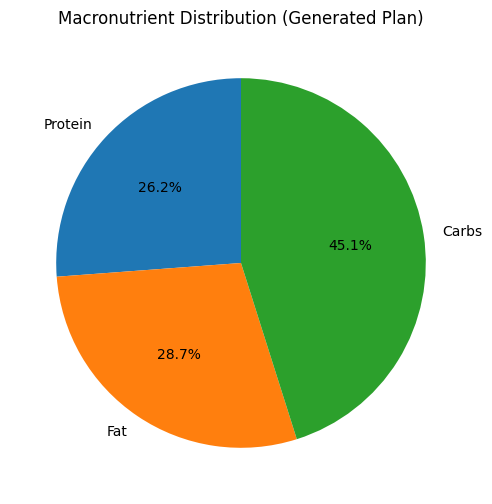

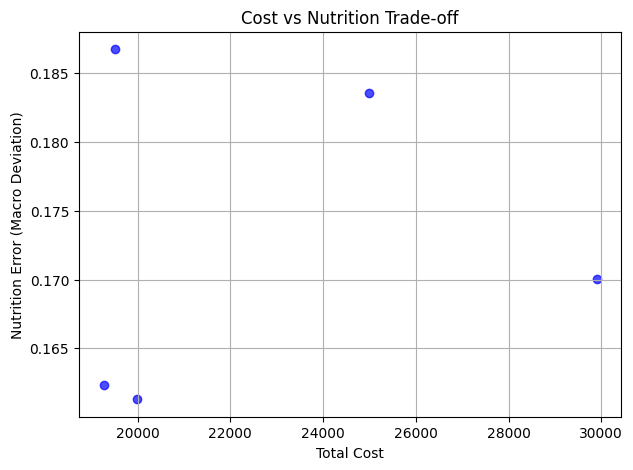

In [199]:

def get_macro_nutrition(transitionmodel, state): # we have two of this one for visulaization and one for the fitness 
    protein_v = 0
    fat_v = 0
    carbs_v = 0
    total_cal = 0
    for day in state:
        total_cal += transitionmodel["Breakfast"][day[0]][2] + transitionmodel["Lunch"][day[1]][2] + transitionmodel["Dinner"][day[2]][2]
        protein_v += transitionmodel["Breakfast"][day[0]][3] + transitionmodel["Lunch"][day[1]][3] + transitionmodel["Dinner"][day[2]][3]
        fat_v     +=transitionmodel["Breakfast"][day[0]][5] + transitionmodel["Lunch"][day[1]][5] + transitionmodel["Dinner"][day[2]][5]
        carbs_v   += transitionmodel["Breakfast"][day[0]][4] + transitionmodel["Lunch"][day[1]][4] + transitionmodel["Dinner"][day[2]][4]
    return [protein_v / total_cal, fat_v / total_cal, carbs_v / total_cal]

def macro_error(meals,state): # we have two also in this we use it in the visualization,fitness,greedy,A*
    macros = get_macro_nutrition(meals,state)

    target = [0.25, 0.35, 0.4]  # example , we can take it from the problem formulation

    error = sum(abs(macros[i] - target[i]) for i in range(3))

    return error

def get_axis_plot(meals):
     costs = []
     errors = []
     i = 10000
     for _ in range(5):  # 30 different solution
        g = GAProblem(recipes_df,i,2000)
        solution,_ = GASearch(g)
        cost = g.get_total_cost(solution)
        error = macro_error(meals,solution)
        i += 5000 
        costs.append(cost)
        errors.append(error)
     return costs,errors

meals_details = TransitionModel # we caluclate for each prblem except the CSP
labels = ['Protein', 'Fat', 'Carbs']
values = get_macro_nutrition(meals_details,solution)
plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Macronutrient Distribution (Generated Plan)')
plt.show()
x_axis,y_axis = get_axis_plot(meals_details)
plt.figure(figsize=(7,5))
plt.scatter(x_axis, y_axis, color='blue', alpha=0.7)
plt.xlabel("Total Cost")
plt.ylabel("Nutrition Error (Macro Deviation)")
plt.title("Cost vs Nutrition Trade-off")
plt.grid(True)
plt.show()


# A* and Greedy

# Node Class

In [200]:
class MealPlannerState:
    def __init__(self, day_number, meal_type, meal, remaining_budget, today_calorie_use, today_protein_use, today_carbs_use, today_fat_use, used_meals = None):
        self.day = day_number
        self.meal_type = meal_type
        self.meal = meal
        self.remaining_budget = remaining_budget
        self.today_calorie_use = today_calorie_use
        self.today_protein_use = today_protein_use
        self.today_carbs_use = today_carbs_use
        self.today_fat_use = today_fat_use
        self.used_meals = used_meals
        
    def __eq__(self, other):
        return isinstance(other, MealPlannerState) and \
            self.day == other.day and \
            self.meal_type == other.meal_type and \
            self.meal == other.meal

    def __hash__(self):
        return hash((self.day, self.meal_type, self.meal))

class Node:    
    def __init__(self, state, parent=None, action=None, cost=0, heuristic=0):
        self.state = state
        self.parent = parent
        self.action = action
        self.g = (parent.g + cost) if parent else 0
        self.f = self.g + heuristic
        self.depth = 0 if parent is None else parent.depth + 1

    def path(self):
        node = self
        actions = []
        while node.parent is not None:
            actions.append(node.action)
            node = node.parent
        actions.reverse()
        return actions

    def __lt__(self, other):
        return self.f < other.f

    def __eq__(self, other):
        return isinstance(other, Node) and self.state == other.state

    def __hash__(self):
        return hash(self.state)


# Problem Class

In [201]:
class MealPlanningProblem:

    def __init__(self, transition_model, TDEE, total_budget, num_days=7, macroNutri_preference="maintain"):
        self.transition_model = transition_model
        self.total_budget = total_budget
        self.TDEE = TDEE
        self.num_days = num_days
        self.meals_per_day = 3  # Breakfast, Lunch, Dinner
        self.total_slots = num_days * self.meals_per_day
        self.meal_types = ['Breakfast', 'Lunch', 'Dinner']

        self.meal_type_weights = {
            'Breakfast': 0.25,
            'Lunch': 0.40,
            'Dinner': 0.35
        }

        self.macro_nutrients_ratios = NUTRI_PREFERENCE_MAP[macroNutri_preference]

        self.initial_state = MealPlannerState(0, 0, None, total_budget, 0, 0, 0, 0, set())
        
        self._avg_price = recipes_df['total_price'].mean()

    def _get_remaining_days(self, state):
        current_slot = state.day * self.meals_per_day + state.meal_type + 1
        remaining_slots = self.total_slots - current_slot
        return math.ceil(remaining_slots / self.meals_per_day)

    def _calculate_totals(self, recipes_list):
        total_cost = 0
        total_calories = 0
        
        i = 0
        for meal_name in recipes_list:
            recipe = self.transition_model[self.meal_types[i]][meal_name]
            total_cost += recipe[1]
            total_calories += recipe[2]
            
            i = (i+1)%3

        return total_cost, total_calories

    def is_goal(self, node):
        state = node.state
        
        if state.day < self.num_days:
            return False
        
        recipes_chosen = node.path()
        
        if len(recipes_chosen) != self.total_slots:
            return False
        
        total_cost, total_calories = self._calculate_totals(recipes_chosen)
        
        goal_calories = self.TDEE * self.num_days
        calorie_tolerance = goal_calories * 0.1
        calories_ok = abs(total_calories - goal_calories) <= calorie_tolerance or True
        
        budget_ok = total_cost <= self.total_budget
        
        return calories_ok and budget_ok

    def expand_node(self, node, use_cost=True, use_heuristic=False):
        state = node.state
        
        if state.day >= self.num_days:
            return []
        
        children = []
        valid_actions = self.transition_model[self.meal_types[node.state.meal_type]]
        
        for meal_name in valid_actions:

            if meal_name in state.used_meals:
                continue

            recipe = self.transition_model[self.meal_types[node.depth%3]][meal_name]
            
            action_cost = self.calculate_cost(node.state, meal_name) if use_cost else 0
            
            new_meal_idx = (state.meal_type + 1) % self.meals_per_day
            new_day = state.day if new_meal_idx > 0 else state.day + 1
            new_remaining_budget = state.remaining_budget - recipe[1]
            new_calorie_use = 0 if new_meal_idx == 0 else state.today_calorie_use + recipe[2]
            new_protein_use = 0 if new_meal_idx == 0 else state.today_protein_use + recipe[3]
            new_carbs_use = 0 if new_meal_idx == 0 else state.today_carbs_use + recipe[4]
            new_fat_use = 0 if new_meal_idx == 0 else state.today_fat_use + recipe[5]
            
            if new_day % 15 == 0 and new_day != 0:
                new_used_meals = set({})
            else:
                new_used_meals = set(state.used_meals)

            new_used_meals.add(meal_name)
            
            new_state = MealPlannerState(new_day, new_meal_idx, meal_name, new_remaining_budget,
            new_calorie_use, new_protein_use, new_carbs_use, new_fat_use, new_used_meals)
            
            heuristic = self.calculate_heuristic(new_state) if use_heuristic else 0
            
            child = Node(new_state, parent=node, action=meal_name, cost=action_cost, heuristic=heuristic)
            children.append(child)
        
        return children

    def calculate_cost(self, state, meal_name=None):
        if meal_name is None:
            meal_name = state.meal
        
        if meal_name is None:
            return 0
        
        recipe = self.transition_model[self.meal_types[state.meal_type]][meal_name]
        meal_type = self.meal_types[state.meal_type]
        
        remaining_days = self._get_remaining_days(state)
        
        allocated_price = self.meal_type_weights[meal_type] * (state.remaining_budget / max(1, remaining_days))
        allocated_calories = self.meal_type_weights[meal_type] * self.TDEE 

        allocated_protein = self.meal_type_weights[meal_type] * self.TDEE * self.macro_nutrients_ratios["protein"]
        allocated_carbs = self.meal_type_weights[meal_type] * self.TDEE * self.macro_nutrients_ratios["carbs"]
        allocated_fat = self.meal_type_weights[meal_type] * self.TDEE * self.macro_nutrients_ratios["fat"]

        price_deviation = abs(recipe[1] - allocated_price)
        calorie_deviation = abs(recipe[2] - allocated_calories)
        protein_deviation = abs(recipe[3] - allocated_protein)
        carbs_deviation = abs(recipe[4] - allocated_carbs)
        fat_deviation = abs(recipe[5] - allocated_fat)

        normalized_price_dev = price_deviation / allocated_price if allocated_price > 0 else 0
        normalized_cal_dev = calorie_deviation / allocated_calories if allocated_calories > 0 else 0
        normalized_protein_dev = protein_deviation / allocated_protein if allocated_protein > 0 else 0
        normalized_carbs_dev = carbs_deviation / allocated_carbs if allocated_carbs > 0 else 0
        normalized_fat_dev = fat_deviation / allocated_fat if allocated_fat > 0 else 0

        total_cost = (normalized_price_dev + normalized_cal_dev + normalized_protein_dev + normalized_carbs_dev + normalized_fat_dev) / 5.0
        
        return total_cost


    def calculate_heuristic(self, state):
        remaining_slots = self.total_slots - (state.day * self.meals_per_day + state.meal_type)
        if remaining_slots <= 0:
            return 0

        ideal_spend = state.remaining_budget / remaining_slots

        # price_gap = abs(self._avg_price - ideal_spend) / self._avg_price
        calorie_gap = abs(state.today_calorie_use - self.TDEE) / self.TDEE
        protein_gap = abs(state.today_protein_use - (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["protein"])) / (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["protein"]) if (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["protein"]) > 0 else 0
        carbs_gap = abs(state.today_carbs_use - (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["carbs"])) / (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["carbs"]) if (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["carbs"]) > 0 else 0
        fat_gap = abs(state.today_fat_use - (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["fat"])) / (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["fat"]) if (self.meal_type_weights[self.meal_types[state.meal_type]] * self.TDEE * self.macro_nutrients_ratios["fat"]) > 0 else 0

        return ( calorie_gap + protein_gap + carbs_gap + fat_gap) / 4.0

        # return (price_gap + calorie_gap) / 2.0


# Problem Class

In [202]:
import queue

class AstarSearch:
    def __init__(self,problem):
        self.problem = problem
        self.frontier = queue.PriorityQueue()

        self.explored = set()

    def search(self):

        node = Node(self.problem.initial_state)
        self.frontier.put(node)
        
        while True:
            if self.frontier.empty():
                return None

            node = self.frontier.get()
            
            if self.problem.is_goal(node):
                solution = self._get_solution_path(node)
                return solution

            self.explored.add(node.state)

            children = self.problem.expand_node(node, True, True)

            for child in children:
                if child.state not in self.explored and child not in self.frontier.queue:
                    self.frontier.put(child)

    def _get_solution_path(self, solution_node):
        path = solution_node.path()
        path = [tuple([
                path[i],
                path[i+1],
                path[i+2]
            ]) for i in range(0, len(path), 3)]

        return path

class GreedySearch:
    def __init__(self,problem):
        self.problem = problem
        self.frontier = queue.PriorityQueue()

        self.explored = set()

    def search(self):

        node = Node(self.problem.initial_state)
        self.frontier.put(node)
        
        while True:
            if self.frontier.empty():
                return None

            node = self.frontier.get()
            
            if self.problem.is_goal(node):
                solution = self._get_solution_path(node)
                return solution

            self.explored.add(node.state)

            children = self.problem.expand_node(node, False, True)

            for child in children:
                if child.state not in self.explored and child not in self.frontier.queue:
                    self.frontier.put(child)

    def _get_solution_path(self, solution_node):
        path = solution_node.path()
        path = [tuple([
                path[i],
                path[i+1],
                path[i+2]
            ]) for i in range(0, len(path), 3)]

        return path

# Run Test

In [203]:
def test_search(TDEE, budget, days, strat = "A*"):
    problem = MealPlanningProblem(TransitionModel, TDEE, budget, days)

    S = AstarSearch(problem) if strat == "A*" else GreedySearch(problem)

    solution = S.search()

    if solution is None:
        print("couldn't find a suitable plan")
        return

    # Helper function to find meal info by name
    def find_meal(meal_name):
        for meal_type in TransitionModel:
            if meal_name in TransitionModel[meal_type]:
                return TransitionModel[meal_type][meal_name]
        return None
    
    # Extract recipes from solution and calculate statistics
    recipe_data = []
    for day_meals in solution:
        for meal_name in day_meals:
            meal_info = find_meal(meal_name)
            if meal_info:
                recipe_data.append(meal_info)
    
    # Calculate totals (note: protein, carbs, fat are stored as calorie contributions)
    total_cost = sum(r[1] for r in recipe_data)  # total_price at index 1
    total_calories = sum(r[2] for r in recipe_data)  # provided_calories at index 2
    total_protein_cal = sum(r[3] for r in recipe_data)  # provided_protein (in calories) at index 3
    total_carbs_cal = sum(r[4] for r in recipe_data)  # provided_carbs (in calories) at index 4
    total_fat_cal = sum(r[5] for r in recipe_data)  # provided_fat (in calories) at index 5
    
    # Convert calorie contributions to grams
    total_protein_g = total_protein_cal / 4
    total_carbs_g = total_carbs_cal / 4
    total_fat_g = total_fat_cal / 9
    
    # Calculate macronutrient ratios as percentages of total calories
    actual_protein_ratio = (total_protein_cal / total_calories * 100) if total_calories > 0 else 0
    actual_carbs_ratio = (total_carbs_cal / total_calories * 100) if total_calories > 0 else 0
    actual_fat_ratio = (total_fat_cal / total_calories * 100) if total_calories > 0 else 0
    
    # Get target macronutrient ratios
    target_ratios = NUTRI_PREFERENCE_MAP.get("maintain", {"protein": 0.30, "fat": 0.25, "carbs": 0.45})
    target_protein_pct = target_ratios["protein"] * 100
    target_carbs_pct = target_ratios["carbs"] * 100
    target_fat_pct = target_ratios["fat"] * 100
    
    # Calculate deviations
    expected_calories = TDEE * days
    calorie_deviation = total_calories - expected_calories
    calorie_deviation_pct = (calorie_deviation / expected_calories) * 100 if expected_calories > 0 else 0
    
    budget_remaining = budget - total_cost
    budget_deviation_pct = (budget_remaining / budget) * 100 if budget > 0 else 0
    
    # Macronutrient deviations
    protein_dev = actual_protein_ratio - target_protein_pct
    carbs_dev = actual_carbs_ratio - target_carbs_pct
    fat_dev = actual_fat_ratio - target_fat_pct
    
    # Daily breakdown
    daily_costs = []
    daily_calories = []
    daily_protein = []
    daily_carbs = []
    daily_fat = []
    for i, day_meals in enumerate(solution):
        day_cost = 0
        day_calories = 0
        day_protein_cal = 0
        day_carbs_cal = 0
        day_fat_cal = 0
        for meal_name in day_meals:
            meal_info = find_meal(meal_name)
            if meal_info:
                day_cost += meal_info[1]  # total_price
                day_calories += meal_info[2]  # provided_calories
                day_protein_cal += meal_info[3]  # provided_protein (calories)
                day_carbs_cal += meal_info[4]  # provided_carbs (calories)
                day_fat_cal += meal_info[5]  # provided_fat (calories)
        daily_costs.append(day_cost)
        daily_calories.append(day_calories)
        daily_protein.append(day_protein_cal) 
        daily_carbs.append(day_carbs_cal) 
        daily_fat.append(day_fat_cal)  
    
    # Unique meals
    unique_meals = set(meal_name for day_meals in solution for meal_name in day_meals)
    
    # Print results
    print("="*60)
    print("A* MEAL PLAN RESULTS")
    print("="*60)
    print(f"\n PARAMETERS:")
    print(f"  Daily TDEE target: {TDEE} cal")
    print(f"  Total budget: {budget} DZD")
    print(f"  Duration: {days} days")
    
    print(f"\n COST ANALYSIS:")
    print(f"  Total cost: {total_cost:.2f} DZD")
    print(f"  Budget remaining: {budget_remaining:.2f} DZD ({budget_deviation_pct:.1f}%)")
    print(f"  Average daily cost: {total_cost/days:.2f} DZD")
    
    print(f"\n CALORIE ANALYSIS:")
    print(f"  Total calories: {total_calories:.0f} cal")
    print(f"  Expected calories: {expected_calories} cal")
    print(f"  Deviation: {calorie_deviation:+.0f} cal ({calorie_deviation_pct:+.1f}%)")
    print(f"  Average daily calories: {total_calories/days:.0f} cal")
    
    print(f"\n MACRONUTRIENT DISTRIBUTION:")
    print(f"  Protein: {total_protein_g:.0f} ({actual_protein_ratio:.1f}%) [Target: {target_protein_pct:.0f}%] {protein_dev:+.1f}%")
    print(f"  Carbs:   {total_carbs_g:.0f} ({actual_carbs_ratio:.1f}%) [Target: {target_carbs_pct:.0f}%] {carbs_dev:+.1f}%")
    print(f"  Fat:     {total_fat_g:.0f} ({actual_fat_ratio:.1f}%) [Target: {target_fat_pct:.0f}%] {fat_dev:+.1f}%")
    print(f"\n  Daily Avg Macros:")
    print(f"    Protein: {total_protein_g/days:.0f}g | Carbs: {total_carbs_g/days:.0f}g | Fat: {total_fat_g/days:.0f}g")
    
    print(f"\n DAILY BREAKDOWN:")
    for day in range(days):
        status = "✓" if abs(daily_calories[day] - TDEE) / TDEE < 0.1 else "⚠"
        day_protein_ratio = ((daily_protein[day] / daily_calories[day]) * 100) if daily_calories[day] > 0 else 0
        day_carbs_ratio = ((daily_carbs[day] / daily_calories[day]) * 100) if daily_calories[day] > 0 else 0
        day_fat_ratio = ((daily_fat[day] / daily_calories[day]) * 100) if daily_calories[day] > 0 else 0
        print(f"  Day {day+1}: {daily_costs[day]:.2f} DZD, {daily_calories[day]:.0f} cal {status}")
        print(f"           P:{daily_protein[day]:.0f}g({day_protein_ratio:.0f}%) | C:{daily_carbs[day]:.0f}g({day_carbs_ratio:.0f}%) | F:{daily_fat[day]:.0f}g({day_fat_ratio:.0f}%)")
    
    print(f"\n MEAL DIVERSITY:")
    print(f"  Unique meals: {len(unique_meals)} out of {len(solution) * 3}")
    
    print(f"\nMEAL PLAN:")
    for day in range(days):
        print(f"  Day {day+1}: {solution[day]}")
    print("="*60)

test_search(2200, 7000, 7)

A* MEAL PLAN RESULTS

 PARAMETERS:
  Daily TDEE target: 2200 cal
  Total budget: 7000 DZD
  Duration: 7 days

 COST ANALYSIS:
  Total cost: 6507.68 DZD
  Budget remaining: 492.32 DZD (7.0%)
  Average daily cost: 929.67 DZD

 CALORIE ANALYSIS:
  Total calories: 13653 cal
  Expected calories: 15400 cal
  Deviation: -1747 cal (-11.3%)
  Average daily calories: 1950 cal

 MACRONUTRIENT DISTRIBUTION:
  Protein: 959 (28.1%) [Target: 30%] -1.9%
  Carbs:   1476 (43.2%) [Target: 45%] -1.8%
  Fat:     443 (29.2%) [Target: 25%] +4.2%

  Daily Avg Macros:
    Protein: 137g | Carbs: 211g | Fat: 63g

 DAILY BREAKDOWN:
  Day 1: 996.67 DZD, 1947 cal ⚠
           P:658g(34%) | C:796g(41%) | F:527g(27%)
  Day 2: 926.99 DZD, 2209 cal ✓
           P:577g(26%) | C:904g(41%) | F:760g(34%)
  Day 3: 733.40 DZD, 1633 cal ⚠
           P:469g(29%) | C:664g(41%) | F:519g(32%)
  Day 4: 1160.21 DZD, 1584 cal ⚠
           P:469g(30%) | C:623g(39%) | F:492g(31%)
  Day 5: 1152.85 DZD, 2287 cal ✓
           P:543g(24%)